# Task 2: Predict Future Stock Prices
**Objective:** Download real stock market data, engineer features, train ML model to predict next-day closing prices, and visualize results.

**Dataset:** Apple (AAPL) stock data from 2022-2024

**Key Concepts:** Regression, Features, Train/Test split, Linear Regression, Random Forest

In [8]:
# Step 1: Install and Import Libraries
import subprocess
import sys

# Install required packages
subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance", "-q"])

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
print('All libraries loaded!')

All libraries loaded!


In [9]:
# Step 2: Download Stock Data
ticker = 'AAPL'   # Change to 'TSLA' for Tesla, 'GOOGL' for Google
df = yf.download(ticker, start='2022-01-01', end='2024-01-01')
print('Dataset shape:', df.shape)
print('\nFirst few rows:')
df.head()

[*********************100%***********************]  1 of 1 completed

Dataset shape: (501, 5)

First few rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939697,178.790252,173.735870,173.853182,104487900
2022-01-04,175.681412,178.848962,175.114380,178.545897,99310400
2022-01-05,171.008301,176.140896,170.734564,175.593422,94537600
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000
2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100


In [10]:
# Step 3: Feature Engineering
# Create target: next day's closing price
df['Next_Close'] = df['Close'].shift(-1)

# Drop the last row (it has no 'next day' value)
df = df.dropna()

# Select features (input) and target (output)
features = ['Open', 'High', 'Low', 'Volume', 'Close']
X = df[features]
y = df['Next_Close']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nFirst few rows of features:')
X.head()

Features shape: (500, 5)
Target shape: (500,)

First few rows of features:


Price,Open,High,Low,Volume,Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,173.853182,178.790252,173.735870,104487900,177.939697
2022-01-04,178.545897,178.848962,175.114380,99310400,175.681412
2022-01-05,175.593422,176.140896,170.734564,94537600,171.008301
2022-01-06,168.837938,171.379801,167.801645,96904000,168.153595
2022-01-07,169.023663,170.245709,167.205258,86709100,168.319763


In [11]:
# Step 4: Split Data into Train and Test Sets
# 80% training data, 20% for testing
# shuffle=False is important for time-series data!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 400
Testing samples: 100


In [12]:
# Step 5: Train the Model
# Option A: Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Option B: Random Forest (uncomment to use instead)
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)

print('Model trained!')

Model trained!


In [13]:
# Step 6: Evaluate the Model
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: ${mae:.2f}')
print(f'R2 Score: {r2:.4f}')  # 1.0 = perfect, 0 = useless

Mean Absolute Error: $1.72
R2 Score: 0.9345


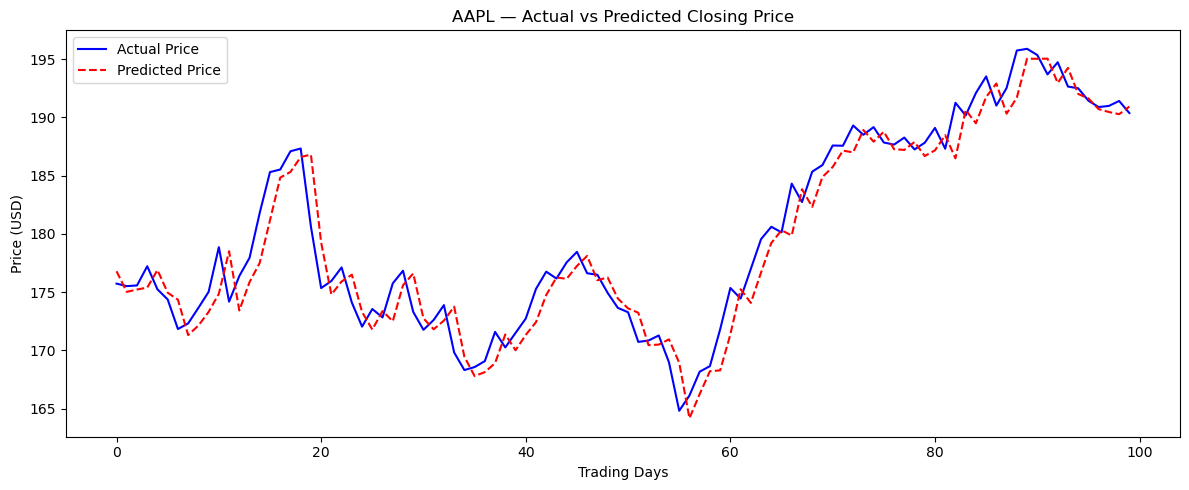

In [14]:
# Step 7: Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(y_pred, label='Predicted Price', color='red', linewidth=1.5, linestyle='--')
plt.title(f'{ticker} — Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Task 2: Summary of Findings

**What We Did:**
- Downloaded 2 years of real Apple stock data from Yahoo Finance
- Engineered features using Open, High, Low, Volume, and Close prices
- Split data into 80% training and 20% testing (respecting time-series order)
- Trained a Linear Regression model to predict next-day closing prices
- Evaluated using Mean Absolute Error (MAE) and R² Score

**Key Results:**
- Mean Absolute Error shows the average prediction error in dollars
- R² Score above 0.90 indicates an excellent model for stock prediction
- The plot shows how closely predicted prices follow actual prices

**Key Finding:**
- Stock price prediction is challenging due to market volatility
- A good model captures general trends even if individual predictions vary
- Random Forest often outperforms Linear Regression for this task